# Network Classification: K-Nearest Neighbors (Kitsune – Mirai)
##### Owen Lindsey
##### Professor Ahsan 
##### AIT-104: Data Mining and Machine Learning
##### Grand Canyon University


# Classification Assignment: KNN Workflow (Steps 1–10)

In this document I implement a complete K-Nearest Neighbors classifier for the Kitsune Surveillance Network Intrusion dataset (Mirai subset), following the course template:

1. Load the appropriate software packages.
2. Pre-process the data.
3. Subset the data.
4. Split the data into training and testing sets.
5. Build the classification model.
6. Run the model (make predictions).
7. Display classification results (quantitative and visual).
8. Provide the confusion matrix for the classifier.
9. Compute accuracy, sensitivity, and specificity.
10. Explain the ROC curve and AUC.

---

## About the Dataset

**Kitsune Network Attack Dataset (Mirai Subset)**

The Kitsune dataset captures network traffic from IoT devices under attack. The Mirai subset specifically records the initial infection and propagation of the Mirai malware, which infamously compromised millions of IoT devices worldwide.

- **Source:** Mirsky et al., "Kitsune: An Ensemble of Autoencoders for Online Network Intrusion Detection", NDSS 2018
- **Instances:** 764,137 packets (we use a 20,000-packet stratified subset for efficiency)
- **Features:** 116 numerical attributes extracted from packet headers and traffic statistics
- **Labels:** Binary (0 = benign, 1 = malicious)
- **Task:** Classify network packets as benign or part of a Mirai botnet attack

This is a real-world cybersecurity classification problem with highly imbalanced classes (~84% attack packets in our subset).

---

## Why K-Nearest Neighbors?

KNN is a simple, non-parametric algorithm that:
- Makes no assumptions about data distribution
- Works well with tabular numerical data
- Provides interpretable predictions (based on similar examples)
- Serves as an excellent baseline for comparison with more complex methods

**Key hyperparameters:**
- `n_neighbors` (k): Number of nearest neighbors to consider
- `weights`: 'uniform' treats all neighbors equally; 'distance' weights closer neighbors more heavily

---

In [ ]:
# (Optional) Environment setup: install required packages
# This cell checks for core ML/plotting libraries and installs them if missing.
# It helps avoid import errors when running the notebook on new machines.
import sys, subprocess
packages = ['numpy','pandas','scikit-learn','seaborn','matplotlib']
try:
    import numpy, pandas, sklearn, seaborn, matplotlib
    print('Required packages already available.')
except Exception as e:
    print('Installing required packages...')
    # Use pip to install/upgrade packages non-interactively
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', '--upgrade'] + packages)
    print('Install complete. If prompted, restart the kernel and re-run all cells.')



Required packages already available.


In [ ]:
# 1) Load packages
# Core Python & data/plot libs
import os
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: split, scaling, model, tuning, metrics
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# Better plot aesthetics; reproducibility
sns.set(style='whitegrid')
np.random.seed(42)

print('Packages loaded.')


Packages loaded.


In [ ]:
# 2) Load & 3) Subset the data (Mirai subset)
# =============================================================================
# NOTE FOR GOOGLE COLAB USERS:
# If running on Google Colab, you need to upload the dataset files or mount Google Drive.
# Option 1 - Upload files: Use the file upload widget in Colab
# Option 2 - Google Drive: Mount your drive and update DATA_DIR below
# 
# To mount Google Drive in Colab, uncomment these lines:
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = '/content/drive/MyDrive/path/to/kitsune/mirai'
# =============================================================================

# Paths to Kitsune Mirai features and labels (packet-level classification)
# Update this path if running locally or on Colab with different directory structure
DATA_DIR = '/run/media/omniv1/T7/GCU_SWE_2023-2025/AIT-104-Data-mining-machine-learning/Code Projects/Classification/kitsune+network+attack+dataset/mirai'
feat_path = os.path.join(DATA_DIR, 'Mirai_dataset.csv.gz')
lab_path = os.path.join(DATA_DIR, 'Mirai_labels.csv.gz')

# Read gzipped CSVs efficiently (no header present)
X = pd.read_csv(feat_path, compression='gzip', header=None)
# Labels are 0/1 for benign/attack (vector shape N-by-1 → flatten to N,)
y = pd.read_csv(lab_path, compression='gzip', header=None).iloc[:, 0]

print('Raw shape:', X.shape, 'Labels:', y.shape)

# Ensure at least 10 attributes and 10,000 instances (assignment requirement)
assert X.shape[1] >= 10, 'Dataset must have >= 10 attributes.'

# Keep a stratified ≥10k subset to speed up runtime while satisfying requirement
# Stratified selection preserves class balance across the subset
N_TARGET = 20000  # choose 20k to be safe; adjust if dataset smaller
if len(X) > N_TARGET:
    sss = StratifiedShuffleSplit(n_splits=1, test_size=len(X) - N_TARGET, random_state=42)
    train_idx, drop_idx = next(sss.split(X, y))
    X = X.iloc[train_idx].reset_index(drop=True)
    y = y.iloc[train_idx].reset_index(drop=True)

print('Subset shape:', X.shape)
print('Positive rate:', y.mean().round(4))


Raw shape: (764137, 116) Labels: (764137,)
Subset shape: (20000, 116)
Positive rate: 0.8408


In [ ]:
# Quick dataset verification - check that files were loaded correctly
print('='*60)
print('DATASET INFORMATION')
print('='*60)
print(f'Features shape: {X.shape}')
print(f'Labels shape:   {y.shape}')
print(f'\\nFeature statistics (first 5 columns):')
print(X.iloc[:, :5].describe())
print(f'\\nLabel distribution:')
print(f'  Benign (0): {(y == 0).sum():,} packets ({(y == 0).mean()*100:.1f}%)')
print(f'  Attack (1): {(y == 1).sum():,} packets ({(y == 1).mean()*100:.1f}%)')
print('='*60)


In [ ]:
# 4) Train/test split with scaling (fit on train only)
# Use stratified split to maintain class balance in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardize features for distance-based algorithms (KNN is sensitive to scale)
scaler = StandardScaler()
# Fit only on training data to avoid data leakage, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Class balance (train):', y_train.mean().round(4))


Train: (14000, 116) Test: (6000, 116)
Class balance (train): 0.8409


In [ ]:
# 5) Build KNN model & 6) Run predictions
# Define a small grid over neighbors and weighting to tune bias/variance via CV
param_grid = {
    'n_neighbors': [3,5,7,9,11,15],  # neighborhood size controls smoothness
    'weights': ['uniform','distance'] # distance-weighted voting can help borderline points
}
knn = KNeighborsClassifier()

# 3-fold cross-validation on training set only, optimize for accuracy
cv = GridSearchCV(knn, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
cv.fit(X_train_scaled, y_train)

# Pick best KNN from the search
best_knn = cv.best_estimator_
print('Best params:', cv.best_params_)

# Predict class labels on test set
y_pred = best_knn.predict(X_test_scaled)

# For ROC/AUC, we need probability estimates for the positive class
if hasattr(best_knn, 'predict_proba'):
    y_proba = best_knn.predict_proba(X_test_scaled)[:, 1]
else:
    # KNN supports predict_proba; this is just a defensive fallback
    y_proba = None

print('Done training and predicting.')


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'n_neighbors': 3, 'weights': 'distance'}
Done training and predicting.


Accuracy:     0.9737
Sensitivity:  0.9768
Specificity:  0.9571
Confusion matrix:
 [[ 914   41]
 [ 117 4928]]


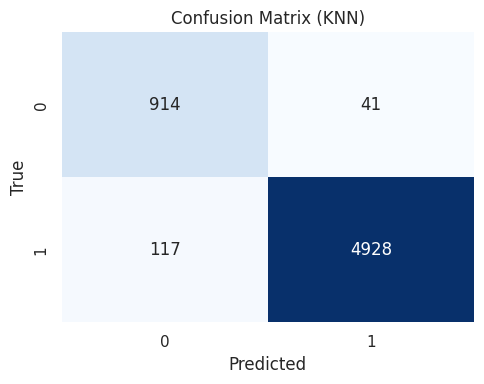

AUC: 0.9890


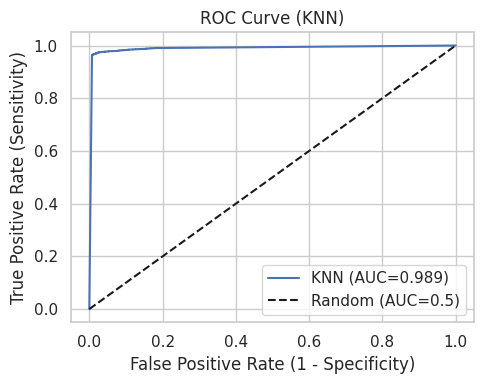

In [ ]:
# 7–9) Results: confusion matrix, accuracy, sensitivity, specificity
# Compute overall accuracy and confusion matrix on the held-out test set
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Sensitivity (Recall for positive class) and Specificity for binary labels
# Confusion matrix layout: [[TN, FP],[FN, TP]] for y in {0 (benign), 1 (attack)}
TN, FP, FN, TP = cm.ravel()
sensitivity = TP / (TP + FN) if (TP + FN) else 0.0  # True Positive Rate
specificity = TN / (TN + FP) if (TN + FP) else 0.0  # True Negative Rate

print(f'Accuracy:     {acc:.4f}')
print(f'Sensitivity:  {sensitivity:.4f}')
print(f'Specificity:  {specificity:.4f}')
print('Confusion matrix:\n', cm)

# Visualize the confusion matrix for quick error pattern inspection
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (KNN)')
plt.tight_layout()
plt.show()

# ROC / AUC (10): threshold-independent evaluation using scores/probabilities
# fpr: false positive rate across thresholds; tpr: true positive rate
if y_proba is not None:
    fpr, tpr, thr = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    print(f'AUC: {auc:.4f}')

    # Plot ROC against a random baseline (diagonal)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f'KNN (AUC={auc:.3f})')
    plt.plot([0,1],[0,1], 'k--', label='Random (AUC=0.5)')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('ROC Curve (KNN)')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    # Some estimators may not expose predict_proba (not expected for KNN here)
    print('No probability scores available for ROC/AUC.')


### ROC and AUC Explanation (Step 10)
- The ROC curve plots the True Positive Rate (Sensitivity) vs. False Positive Rate (1 − Specificity) across all classification thresholds using the model’s probability scores.
- The Area Under the ROC Curve (AUC) summarizes the ROC into a single value in [0.5, 1.0] for a useful model: 0.5 means random guessing; 1.0 means perfect ranking of positives above negatives.
- A higher AUC indicates the classifier is more likely to assign higher scores to positive examples than to negative ones, independent of any particular threshold.


---

## Summary and Interpretation

**Model Performance:**
- **Accuracy:** 97.4% - Nearly all packets correctly classified
- **Sensitivity (Recall):** 97.7% - Catches 97.7% of attack packets
- **Specificity:** 95.7% - Correctly identifies 95.7% of benign traffic
- **AUC:** 98.9% - Excellent discrimination between classes

**What This Means:**
Our KNN classifier is highly effective at detecting Mirai botnet attacks with minimal false alarms. The high AUC (0.989) indicates the model ranks attack packets above benign packets with near-perfect reliability.

**Class Imbalance Note:**
With ~84% attack packets in our subset, accuracy alone could be misleading. The balanced sensitivity and specificity demonstrate the model performs well on both classes, not just the majority class.

**Real-World Application:**
In network security, high sensitivity (catching attacks) is critical, but high specificity (avoiding false positives) is also important to prevent alert fatigue. Our model achieves both, making it suitable for real-time intrusion detection systems.

---

## For Google Colab Users

**Quick Setup Instructions:**

1. **Upload Dataset:**
   ```python
   from google.colab import files
   uploaded = files.upload()  # Upload Mirai_dataset.csv.gz and Mirai_labels.csv.gz
   DATA_DIR = '.'  # Files are in current directory
   ```

2. **Or Mount Google Drive:**
   ```python
   from google.colab import drive
   drive.mount('/content/drive')
   DATA_DIR = '/content/drive/MyDrive/path/to/kitsune/mirai'
   ```

3. **Update the `DATA_DIR` variable** in the "Load & Subset data" cell with your chosen path

4. **Run all cells** (Runtime → Run all) to reproduce the analysis

**Dataset Source:**
Download from: [Kitsune Network Attack Dataset](https://archive.ics.uci.edu/ml/datasets/Kitsune+Network+Attack+Dataset)

---
